In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prince

from importlib.metadata import version
from pathlib import Path
from matplotlib.transforms import offset_copy

import io
import contextlib
from adjustText import adjust_text

In [11]:
%run LittRuP__import_functions.ipynb

In [12]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [13]:

print(f"prince: {version('prince')}")


prince: 0.17.0


In [14]:
# import matrice profil thématique réduit des auteurs

matrix_reduced_profile = pd.read_csv(DAT_DIR / "LittRu_AC_matrix_reduced_profile.csv", sep=',', header=0)

In [15]:
# auteurs en index

matrix_reduced_profile = matrix_reduced_profile.set_index("Author")

**AC partielle sur les points interprétables du plan 1-2 provenant des fichiers**

- _LittRu_AC_auteurs_interpretables_plan_1-2.csv_ (11 auteurs)
- _LittRu_AC_themes_interpretables_plan_1-2.csv_  (4 thèmes)

Ne pas recalculer une nouvelle AC sur les 11 auteurs et les 4 thèmes.
Une nouvelle AC calculée uniquement sur les 11 auteurs et les 4 thèmes produirait une autre géométrie factorielle, avec d’autres coordonnées et d’autres inerties. Elle ne serait donc plus directement comparable au graphique global.

Il faut :

- conserver l’AC calculée sur toute la matrice "atrix_reduced_profile" ;
- conserver les coordonnées globales "row_coords" et "col_coords" ;
- utiliser les deux CSV uniquement comme listes de points à mettre en évidence ;
- afficher tous les autres points en gris clair.

Ainsi, les coordonnées, les distances entre points et les pourcentages d’inertie restent exactement ceux de l’AC globale.

**Programme de construction de l'AC**

In [16]:
# ============================================================
# 1. AC globale
# ============================================================

# sécurité : supprimer lignes ou colonnes nulles éventuelles
X_CA = matrix_reduced_profile.copy()

X_CA = X_CA.loc[
    X_CA.sum(axis=1) > 0,
    X_CA.sum(axis=0) > 0
]

# AC
ca = prince.CA(
    n_components=2,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=0
)

ca = ca.fit(X_CA)

# coordonnées globales des auteurs et des thèmes
row_coords = ca.row_coordinates(X_CA)
col_coords = ca.column_coordinates(X_CA)

# pourcentages d'inertie expliquée par les axes
pct = ca.percentage_of_variance_

# ============================================================
# 2. Importation des listes de points interprétables
# ============================================================

authors_interpretables_df = pd.read_csv(
    DAT_DIR
    / "LittRu_AC_auteurs_interpretables_plan_1-2.csv"
)

themes_interpretables_df = pd.read_csv(
    DAT_DIR
    / "LittRu_AC_themes_interpretables_plan_1-2.csv"
)

# suppression d'éventuels espaces parasites
authors_interpretables_df["Author"] = (
    authors_interpretables_df["Author"]
    .astype(str)
    .str.strip()
)

themes_interpretables_df["Theme"] = (
    themes_interpretables_df["Theme"]
    .astype(str)
    .str.strip()
)

# listes des noms retenus
authors_interpretables = (
    authors_interpretables_df["Author"]
    .tolist()
)

themes_interpretables = (
    themes_interpretables_df["Theme"]
    .tolist()
)

# Les colonnes de contributions et de cos² ne sont pas nécessaires ici : 
# la sélection a déjà été effectuée. Seules les colonnes Author et Theme servent à repérer les points.

# ============================================================
# 3. Vérification de la concordance des noms
# ============================================================

authors_absents = []

for author in authors_interpretables:

    if author not in row_coords.index:
        authors_absents.append(author)


themes_absents = []

for theme in themes_interpretables:

    if theme not in col_coords.index:
        themes_absents.append(theme)


if len(authors_absents) > 0:

    print(
        "Auteurs absents des coordonnées de l'AC :",
        authors_absents
    )


if len(themes_absents) > 0:

    print(
        "Thèmes absents des coordonnées de l'AC :",
        themes_absents
    )

# Cette vérification permet notamment de repérer une différence d’accentuation, 
# d’espace ou de graphie entre les CSV et les index de la matrice.

# ============================================================
# 4. Séparation des points interprétables
#    et des points placés en arrière-plan
# ============================================================

mask_authors_interpretables = (
    row_coords.index.isin(authors_interpretables)
)

# le masque contient une valeur booléenne (TRUE, FALSE) pour chaque auteur :
# True : l’auteur appartient à la liste des auteurs interprétables ;
# False : il n’y appartient pas.
# idem pour le masque des thèmes...

mask_themes_interpretables = (
    col_coords.index.isin(themes_interpretables)
)

# auteurs retenus
row_coords_interpretables = row_coords.loc[
    mask_authors_interpretables
]

# auteurs non retenus
row_coords_background = row_coords.loc[
    ~mask_authors_interpretables
]

# en plaçant " ~ " devant le masque, on inverse toutes les valeurs, d'où :
# sélectionner dans row_coords tous les auteurs qui ne sont PAS interprétables
# idem pour les thèmes...

# thèmes retenus
col_coords_interpretables = col_coords.loc[
    mask_themes_interpretables
]

# thèmes non retenus
col_coords_background = col_coords.loc[
    ~mask_themes_interpretables
]


**Programme de construction du graphique**

Dans la version suivante :

- les 8 auteurs interprétables sont en vert ;
- les 4 thèmes interprétables sont en rouge ;
- les autres auteurs et thèmes restent visibles en gris clair ;
- seuls les points interprétables reçoivent un label ;
- adjust_text évite néanmoins l’ensemble des points de l’AC.

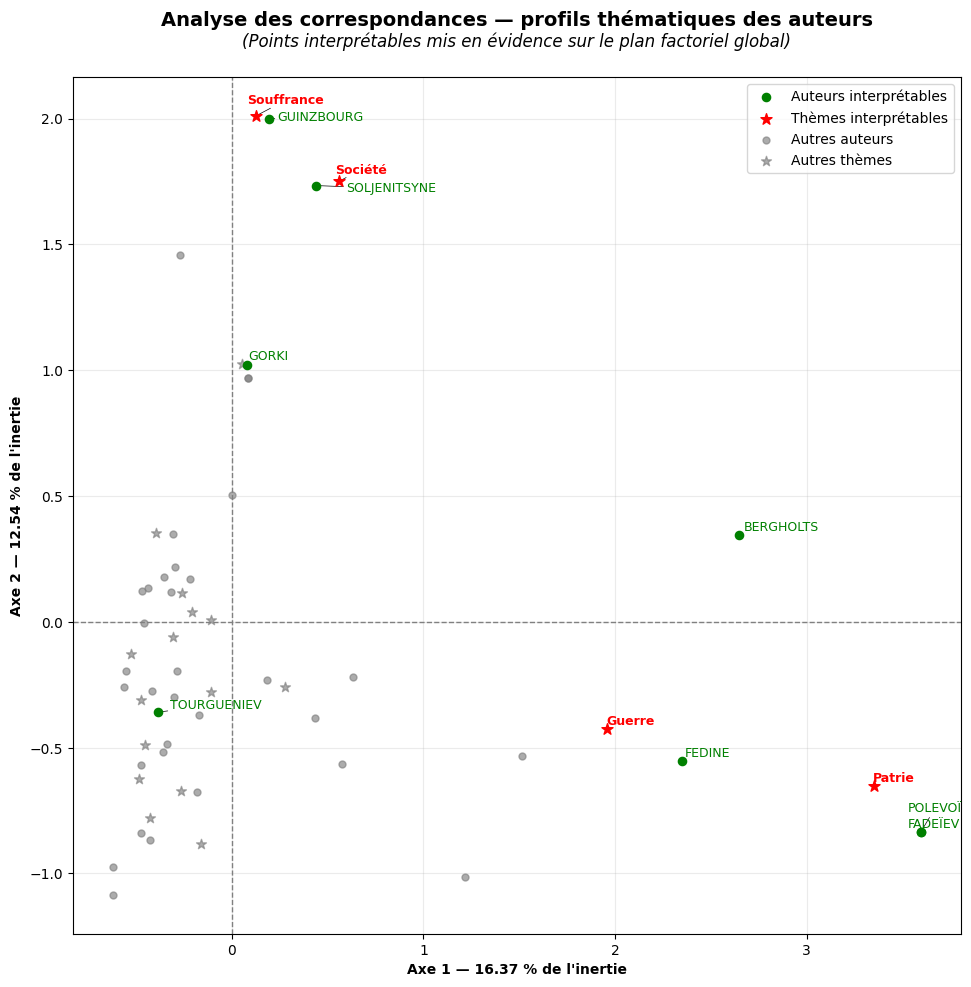

In [18]:
# ============================================================
# 5. Graphique de l'AC globale avec mise en évidence
#    des points interprétables
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))


# ------------------------------------------------------------
# Points interprétables
# ------------------------------------------------------------

# auteurs interprétables
ax.scatter(
    row_coords_interpretables[0],
    row_coords_interpretables[1],
    s=35,
    marker="o",
    color="green",
    alpha=1.0,
    label="Auteurs interprétables",
    zorder=3
)

# thèmes interprétables
ax.scatter(
    col_coords_interpretables[0],
    col_coords_interpretables[1],
    s=70,
    marker="*",
    color="red",
    alpha=1.0,
    label="Thèmes interprétables",
    zorder=3
)


# ------------------------------------------------------------
# Points non retenus en arrière-plan
# ------------------------------------------------------------

# autres auteurs
ax.scatter(
    row_coords_background[0],
    row_coords_background[1],
    s=25,
    marker="o",
    color="gray",
    alpha=0.65,
    label="Autres auteurs",
    zorder=1
)

# autres thèmes
ax.scatter(
    col_coords_background[0],
    col_coords_background[1],
    s=55,
    marker="*",
    color="gray",
    alpha=0.65,
    label="Autres thèmes",
    zorder=1
)

# ------------------------------------------------------------
# Labels des seuls points interprétables
# ------------------------------------------------------------

textes_auteurs = []
textes_themes = []


# labels des auteurs interprétables
for author in row_coords_interpretables.index:

    texte = ax.text(
        row_coords_interpretables.loc[author, 0],
        row_coords_interpretables.loc[author, 1],
        author,
        color="green",
        fontsize=9,
        alpha=1.0,
        zorder=4
    )

    textes_auteurs.append(texte)


# labels des thèmes interprétables
for theme in col_coords_interpretables.index:

    texte = ax.text(
        col_coords_interpretables.loc[theme, 0],
        col_coords_interpretables.loc[theme, 1],
        theme,
        color="red",
        fontsize=9,
        fontweight="bold",
        alpha=1.0,
        zorder=4
    )

    textes_themes.append(texte)

# ------------------------------------------------------------
# Axes, titres et légende
# ------------------------------------------------------------

ax.axhline(
    0,
    linewidth=1.0,
    linestyle="--",
    color="gray"
)

ax.axvline(
    0,
    linewidth=1.0,
    linestyle="--",
    color="gray"
)

ax.set_xlabel(
    f"Axe 1 — {pct[0]:.2f} % de l'inertie",
    fontweight="bold"
)

ax.set_ylabel(
    f"Axe 2 — {pct[1]:.2f} % de l'inertie",
    fontweight="bold"
)

ax.legend()

ax.grid(
    alpha=0.25
)

# ------------------------------------------------------------
# Ajustement automatique des labels
# ------------------------------------------------------------

fig.tight_layout(
    rect=[0, 0, 1, 0.93]
)

fig.canvas.draw()


# seuls les labels interprétables sont déplacés
textes_tous = textes_auteurs + textes_themes


# mais tous les points du graphique doivent être évités
x_points = (
    list(row_coords[0])
    + list(col_coords[0])
)

y_points = (
    list(row_coords[1])
    + list(col_coords[1])
)


with contextlib.redirect_stdout(io.StringIO()):

    adjust_text(
        textes_tous,
        x=x_points,
        y=y_points,
        ax=ax,
        expand=(1.20, 1.20),
        force_text=(0.25, 0.25),
        force_static=(0.20, 0.20),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            linewidth=0.5,
            alpha=1.0
        )
    )

# ------------------------------------------------------------
# Titre général et export
# ------------------------------------------------------------

titres(
    fig,
    ax,
    t1=(
        "Analyse des correspondances — "
        "profils thématiques des auteurs"
    ),
    y1=37,
    t2=(
        "(Points interprétables mis en évidence "
        "sur le plan factoriel global)"
    ),
    y2=22,
    t3=" ",
    y3=7
)

fig.savefig(
    IMG_DIR
    / "auteurs_themes_AC_points_interpretables.png",
    dpi=300
)

plt.show()

Ce que représente précisément ce graphique

Il ne s’agit pas d’une « AC des points interprétables », mais d’une :

_représentation des points interprétables sur le plan factoriel de l’AC globale._

Cette formulation est importante :
- les 8 auteurs et les 4 thèmes conservent leur position dans l’analyse initiale ;
- les autres points sont seulement atténués visuellement.